In [25]:
import gzip
import matplotlib.pyplot as plt
import numpy as np

In [53]:

with gzip.open('../data/train-images-idx3-ubyte.gz','r') as fin:
    data = fin.read()
with gzip.open('../data/train-labels-idx1-ubyte.gz','r') as fin:
    labels = fin.read()


In [ ]:
def get_label(data: list[bytes], index: int) -> int:
    magic_number = int.from_bytes(data[0:4])
    assert magic_number == 2049
    n_images = int.from_bytes(data[4:8])
    assert index > 0, f"dataset has index from {0} to {n_images - 1}. {index} given"
    assert index < n_images, f"dataset has index from {0} to {n_images - 1}. {index} given"
    return int(data[8 + index])


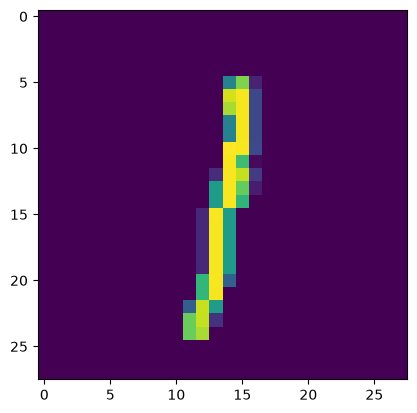

In [54]:
def get_image(data: list[bytes], index: int) -> list[list[float]]:
    magic_number = int.from_bytes(data[0:4])
    assert magic_number == 2051, "File is not an image dataset file"
    n_images = int.from_bytes(data[4:8])
    assert index > 0, f"dataset has index from {0} to {n_images - 1}. {index} given"
    assert index < n_images, f"dataset has index from {0} to {n_images - 1}. {index} given"
    n_rows = int.from_bytes(data[8:12])
    n_cols = int.from_bytes(data[12:16])
    img = data[((index * image_size) + start):(start + image_size + (index * image_size))]
    img2d = [
        [int(pixel)/255 for pixel in img[(i * n_rows):((i + 1) * n_rows)]]  for i in range(n_cols)
    ]
    return img2d

plt.imshow(get_image(data, 124))

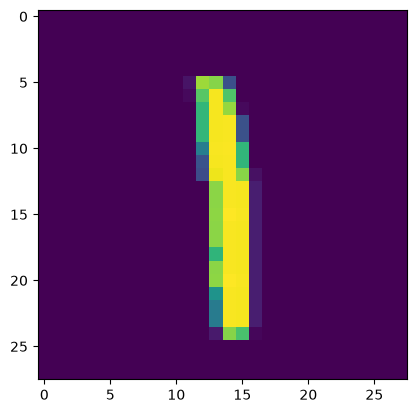

In [44]:

int.from_bytes(data[:4])
n_rows = int.from_bytes(data[8:12])
n_cols = int.from_bytes(data[12:16])
image_size = n_rows * n_cols
start = 16
img_count = 37
img = data[((img_count * image_size) + start):(start + image_size + (img_count * image_size))]
plt.imshow(np.array([k for k in img]).reshape(n_rows, n_cols) / 255)

In [ ]:
data[3]

0

In [27]:
28*28

784